In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.linear_model import SGDClassifier, LinearRegression, RidgeClassifier, ElasticNet, BayesianRidge, SGDRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, root_mean_squared_error, mean_squared_error, ConfusionMatrixDisplay

In [143]:
dataset = load_wine()

x = dataset.data
y = dataset.target

In [ ]:
dataset = load_diabetes()

x = dataset.data
y = dataset.target

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True)
#MODELOS
#model = svm.SVC()
# model = SGDClassifier()
model = RidgeClassifier()


#METRICAS
acc = []
f1score = []

x_array = x.to_numpy() if isinstance(x, pd.DataFrame) else x
y_array = np.array(y)
for i, (train_index, test_index) in enumerate(kf.split(x_array, y_array)):

    x_train_fold, x_test_fold = x_array[train_index], x_array[test_index]
    y_train_fold, y_test_fold = y_array[train_index], y_array[test_index]

    #TRANSFORMAÇÃO DOS DADOS PARA QUE AS MEDIDAS FIQUEM NO MESMO PARAMETRO DE COMPARAÇÃO(NA MESMA ESCALA)
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_fold)
    x_test_scaled = scaler.transform(x_test_fold)

    #IMPLEMENTAÇÃO DO PCA PARA RETIRAR COLUNAS/DIMENSÃO COM POUCA VARIANCIA(MENOS DADOS PARA PROCESSAR)
    pca = PCA(n_components=4)
    x_train_pca = pca.fit_transform(x_train_scaled)
    x_test_pca = pca.transform(x_test_scaled)


    model.fit(x[train_index], y[train_index])
    result = model.predict(x[test_index])
    acc_f = accuracy_score(y[test_index], result)
    f1s_f = f1_score(y[test_index], result, average="macro")

    acc.append(acc_f)
    f1score.append(f1s_f)

    print(f"média acc: {np.mean(acc)}")
    print(f"média f1_score: {np.mean(f1score)}")
    print(f"=====================")


média acc: 0.9722222222222222
média f1_score: 0.974320987654321
média acc: 0.9861111111111112
média f1_score: 0.9871604938271605
média acc: 0.9907407407407408
média f1_score: 0.991440329218107
média acc: 0.9859126984126985
média f1_score: 0.9861078622482131
média acc: 0.9887301587301588
média f1_score: 0.9888862897985705


In [ ]:
kf = KFold(n_splits=5, shuffle=True)
#MODELOS
model = ElasticNet()

#METRICAS
mse = []
rmse = []

x_array = x.to_numpy() if isinstance(x, pd.DataFrame) else x
y_array = np.array(y)
for i, (train_index, test_index) in enumerate(kf.split(x_array, y_array)):

    x_train_fold, x_test_fold = x_array[train_index], x_array[test_index]
    y_train_fold, y_test_fold = y_array[train_index], y_array[test_index]

    #TRANSFORMAÇÃO DOS DADOS
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_fold)
    x_test_scaled = scaler.transform(x_test_fold)

    #IMPLEMENTAÇÃO DO PCA
    pca = PCA(n_components=2)
    x_train_pca = pca.fit_transform(x_train_scaled)
    x_test_pca = pca.transform(x_test_scaled)


    model.fit(x[train_index], y[train_index])
    result = model.predict(x[test_index])
    mse_f = mean_squared_error(y[test_index], result)
    rmse_f = root_mean_squared_error(y[test_index], result)

    mse.append(mse_f)
    rmse.append(rmse_f)

    print(f"média mse: {np.mean(mse)}")
    print(f"média rmse: {np.mean(rmse)}")
    print(f"=====================")

    x_scaled_df = scaler.transform(x_array)
    x_pca_df = pca.transform(x_scaled_df)

    df_plot = pd.DataFrame(
        x_pca_df, 
        columns=["PC1", "PC2"]
    )

    df_plot["class"] = y_array

    sns.pairplot(df_plot, hue="class", palette="rainbow")
    plt.show()

In [145]:
x_scaled_df = scaler.transform(x_array)
x_pca_df = pca.transform(x_scaled_df)

In [147]:
df_plot = pd.DataFrame(
    x_pca_df, 
    columns=["PC1", "PC2", "PC3", "PC4"]
)

In [148]:
df_plot["class"] = y_array

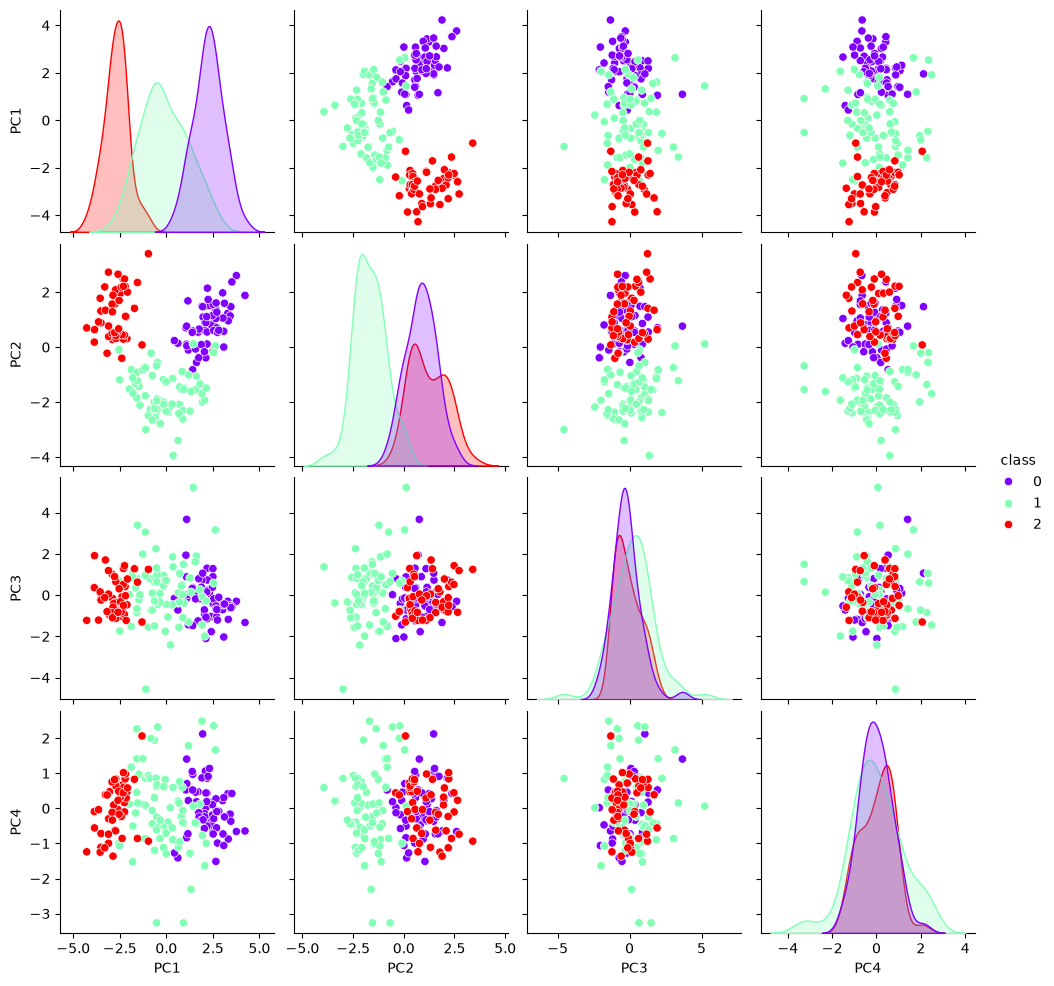

In [149]:
sns.pairplot(df_plot, hue="class", palette="rainbow")
plt.show()